# Decision Tree Regression

In [1]:
from warnings import filterwarnings
filterwarnings("ignore")

# Step 1 - Data Ingestion

In [3]:
import pandas as pd
df = pd.read_csv("PowerPlant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


# Features
1. AT - Ambient Temperature degree celsius
2. V - Vacuum Pressure Pascals
3. AP - Atmospheric Pressure Pascals
4. RH - Relative Humidity Percentage
5. PE - Power Output in MW

# Step 2 - Perfom basic data quality checks

In [4]:
df.duplicated().sum()

np.int64(41)

In [5]:
df = df.drop_duplicates(keep="first").reset_index(drop = True)
df.shape

(9527, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9527 non-null   float64
 1   V       9527 non-null   float64
 2   AP      9527 non-null   float64
 3   RH      9527 non-null   float64
 4   PE      9527 non-null   float64
dtypes: float64(5)
memory usage: 372.3 KB


In [7]:
df.isna().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

# Step 3 - Seperate X and Y

In [8]:
X = df.drop(columns = ["PE"])
Y = df["PE"]

In [9]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [10]:
Y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

# Apply Train Test split

In [11]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [12]:
xtrain.shape

(7621, 4)

In [13]:
xtest.shape

(1906, 4)

# Apply preprocessing on X

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [15]:
num_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
).set_output(transform="pandas")

num_pipe.fit(xtrain)

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [16]:
xtrain_pre = num_pipe.transform(xtrain)
xtrain_pre.head()

,AT,V,AP,RH
5695,-0.154993,0.323693,0.084610,1.818417
7300,-1.504241,-1.151828,0.319064,0.907637
9066,-0.889599,-0.953518,0.288703,0.987193
6424,1.401831,1.221597,-0.485502,-1.086753
6773,-0.828943,-0.940927,0.793033,1.506365


In [17]:
xtest_pre = num_pipe.transform(xtest)
xtest_pre.head()

,AT,V,AP,RH
1087,1.831812,1.118507,-0.131290,-1.419379
6308,-1.508285,-1.243114,0.039069,-0.470879
8021,-1.471891,-1.416242,0.394967,-1.086753
9483,0.149632,0.647127,0.727251,-0.005201
4459,-0.037726,1.126376,-0.367431,1.586607


# Build the model

In [18]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor(
    max_depth = 1,
    min_samples_leaf= 5,
    min_samples_split= 5,
    criterion= "squared_error",
    random_state = 42
)
dtr.fit(xtrain_pre, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,5
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [19]:
dtr.score(xtrain_pre, ytrain)

0.71765957297802

In [20]:
dtr.score(xtest_pre, ytest)

0.7251450398190283

# Evaluate the model

In [21]:
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

def evaluate_model(model, x, y):
    ypred = model.predict(x)
    rmse = root_mean_squared_error(y, ypred)
    mae = mean_absolute_error(y, ypred)
    mape = mean_absolute_percentage_error(y, ypred)
    r2 = r2_score(y, ypred)
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"MAPE : {mape:.2%}")
    print(f"R2 : {r2:.2%}")

In [22]:
evaluate_model(dtr, xtrain_pre, ytrain)

RMSE : 9.01
MAE : 7.37
MAPE : 1.62%
R2 : 71.77%


In [23]:
evaluate_model(dtr, xtest_pre, ytest)

RMSE : 9.11
MAE : 7.36
MAPE : 1.61%
R2 : 72.51%


# Hyperparameter tuning

In [52]:
params = {
    "max_depth": [8, 9, 10, 11, 12, 13],
    "min_samples_split": [5, 6, 7, 8, 9],
    "min_samples_leaf": [5, 6, 7, 8, 9],
    "criterion": ["squared_error", "absolute_error"]
}

In [53]:
from sklearn.model_selection import RandomizedSearchCV

model = DecisionTreeRegressor(random_state=42)
rscv = RandomizedSearchCV(model, params, cv=5, scoring="r2")
rscv.fit(xtrain_pre, ytrain)

,estimator,DecisionTreeR...ndom_state=42)
,param_distributions,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [8, 9, ...], 'min_samples_leaf': [5, 6, ...], 'min_samples_split': [5, 6, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [55]:
rscv.best_params_

{'min_samples_split': 6,
 'min_samples_leaf': 8,
 'max_depth': 10,
 'criterion': 'squared_error'}

In [56]:
rscv.best_score_

np.float64(0.9406048437530872)

In [57]:
best_dtr = rscv.best_estimator_
best_dtr

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,6
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


# Evalute the model

In [58]:
evaluate_model(best_dtr, xtrain_pre, ytrain)

RMSE : 3.24
MAE : 2.36
MAPE : 0.52%
R2 : 96.35%


In [59]:
evaluate_model(best_dtr, xtest_pre, ytest)

RMSE : 3.91
MAE : 2.90
MAPE : 0.64%
R2 : 94.92%


# Plot the decision Tree

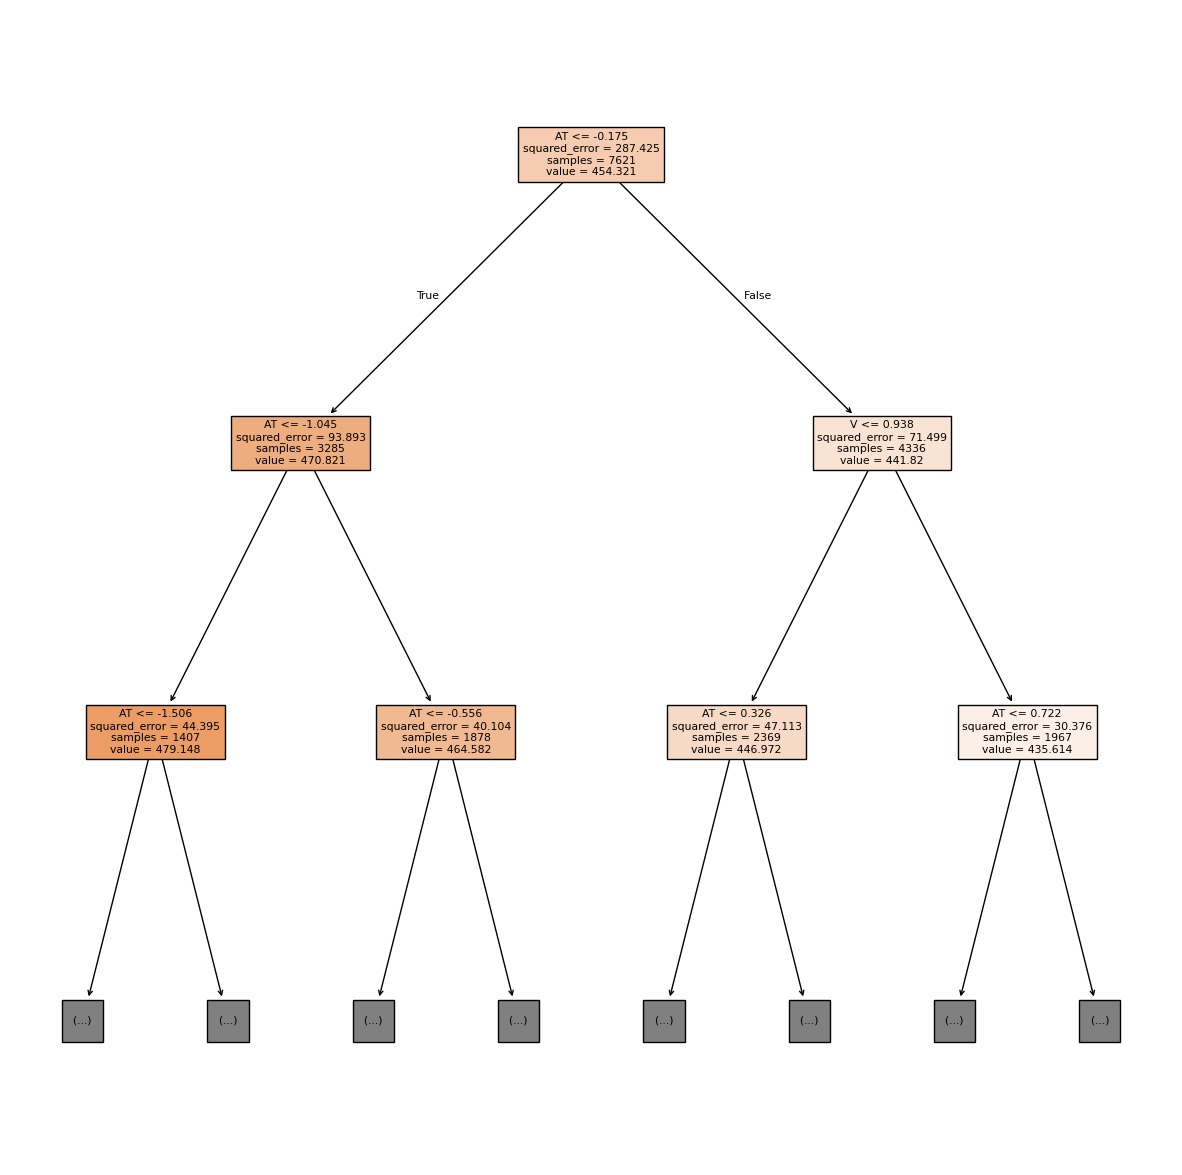

In [60]:
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree

plt.figure(figsize = (15, 15))
plot_tree(best_dtr, feature_names=xtrain_pre.columns, max_depth=2, filled=True)
plt.show()

In [61]:
best_dtr.feature_importances_

array([0.89418641, 0.0870706 , 0.01099511, 0.00774788])

In [62]:
xtrain.columns

Index(['AT', 'V', 'AP', 'RH'], dtype='object')

In [63]:
imp = pd.Series(best_dtr.feature_importances_, index = xtrain.columns)
imp

AT    0.894186
V     0.087071
AP    0.010995
RH    0.007748
dtype: float64

<Axes: >

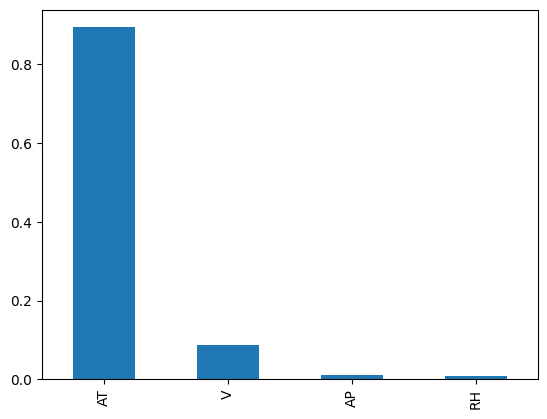

In [64]:
imp.plot(kind = "bar")

# Out of sample prediction

In [65]:
xnew = pd.read_csv("test_PowerPlant.csv")
xnew.head()

,AT,V,AP,RH
0,22.49,58.82,1009.73,85.19
1,28.88,54.89,1007.16,46.60
2,27.89,73.21,1001.32,85.88
3,25.69,62.26,1011.38,74.08
4,12.16,40.81,1025.79,70.97


In [66]:
num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [67]:
xnew_pre = num_pipe.transform(xnew)
xnew_pre.head()

,AT,V,AP,RH
0,0.380123,0.355958,-0.596825,0.810249
1,1.241431,0.046688,-1.030313,-1.836363
2,1.107989,1.488371,-2.015358,0.857571
3,0.811451,0.626666,-0.318516,0.048294
4,-1.012258,-1.061330,2.112049,-0.164999


In [68]:
preds = best_dtr.predict(xnew_pre)
preds

array([444.97294118, 438.15909091, 432.79066667, 442.79914286,
       465.58888889, 444.97294118, 450.41247423, 477.4125    ,
       469.779     , 475.0258427 , 454.6245    , 479.10375   ,
       447.14      , 438.37692308, 432.265     , 429.51714286,
       450.41247423, 464.047     , 440.10666667, 433.39245902,
       435.12139535, 473.08875   , 480.745     , 433.33285714,
       468.5925    , 442.79914286, 440.425     , 430.4225    ,
       440.865     , 443.47785714, 483.1852    , 463.94      ,
       438.12090909, 443.18010417, 435.12139535, 443.58      ,
       467.00727273, 469.924375  , 436.60461538, 472.22272727,
       452.94076923, 454.6245    , 482.97647059, 434.85787879,
       453.71      , 443.18010417, 455.93310345, 450.04058824,
       453.71      , 456.30181818, 477.56451754, 458.395     ,
       472.57132075, 461.91392157, 467.66884615, 444.3325    ,
       432.90625   , 447.72214286, 469.924375  , 473.4025    ,
       447.8625    , 431.484     , 458.61      , 450.04

In [69]:
xnew["PE_pred"] = preds.round(2)

In [70]:
xnew

,AT,V,AP,RH,PE_pred
0,22.49,58.82,1009.73,85.19,444.97
1,28.88,54.89,1007.16,46.60,438.16
2,27.89,73.21,1001.32,85.88,432.79
3,25.69,62.26,1011.38,74.08,442.80
4,12.16,40.81,1025.79,70.97,465.59
...,...,...,...,...,...
95,26.35,69.48,1008.45,70.47,433.74
96,11.78,39.96,1011.37,82.95,475.03
97,5.62,41.38,1020.91,86.21,489.02
98,24.96,74.99,1008.25,80.52,436.77


In [71]:
xnew.to_csv("results.csv", index = False)

# Save the model object

In [72]:
import joblib
joblib.dump(num_pipe, "pre.joblib")

['pre.joblib']

In [73]:
joblib.dump(best_dtr, "dtr_model.joblib")

['dtr_model.joblib']

# Load the model

In [74]:
p = joblib.load("pre.joblib")
p

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [75]:
m = joblib.load("dtr_model.joblib")
m

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,6
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0
